# NLP Course 1 - Week 1 Alternative Assignment

## Movie Review Sentiment Analysis with Logistic Regression

---

## Assignment Overview

**Your Mission**: Build a sentiment analysis classifier for **movie reviews** using Logistic Regression from scratch. Instead of tweets, you'll work with longer, richer text from actual movie reviews.

**Key Difference from Original**: Movie reviews are typically 100-500 words (vs 10-30 words for tweets), contain more complex sentence structures, and use different vocabulary patterns. This will test whether you truly understand the concepts or just memorized tweet-specific implementations.

**Expected Time**: 4-6 hours

**Difficulty**: Intermediate (with gotchas 😈)

---

## Learning Objectives

By completing this assignment, you will demonstrate mastery of:

1. **Text Preprocessing** - Clean and tokenize movie reviews (different patterns than tweets)
2. **Feature Extraction** - Build frequency dictionaries and extract numerical features
3. **Sigmoid Function** - Implement and understand the core activation function
4. **Gradient Descent** - Train your model from scratch using calculus-based optimization
5. **Model Evaluation** - Test on unseen data and calculate accuracy
6. **Error Analysis** - Understand where and why your model fails

---

## Dataset Specification

### Dataset: IMDB Movie Reviews (Simplified Version)

**Source**: You'll need to create or download a simplified version

**Size**: 2000 reviews (1000 positive + 1000 negative)

**Format**: Two text files or a CSV with columns: `review_text`, `sentiment`

### Dataset Structure

```
reviews.csv
├── review: "This movie was absolutely fantastic! The acting was superb..."
└── sentiment: (1 or positive) or (0 or negative)
```

I downloaded the data from https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data and renamed the file as reviews.csv

### Setup and imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import random
from typing import List, Dict, Tuple, Set
from sklearn.model_selection import train_test_split
import string  

import nltk
# download the stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

[nltk_data] Downloading package stopwords to /home/bidut/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Part 1: Data Preparation and Preprocessing


### Milestone 1.1: Load and Explore the Data

**What to implement:**

1. Load your movie review dataset
2. Split into training (80%) and test (20%) sets
3. Print basic statistics

**Expected output:**

```
Total reviews: 2000
Positive reviews: 1000
Negative reviews: 1000
Training set size: 1600
Test set size: 400
Average review length: 156 words
```

💡 Hint: Use `random.seed()` for reproducible train/test splits

**🎓 Concepts from Week 1 Material**:

- Supervised Learning setup (Section 1)
- Understanding features (X) and labels (Y)

In [2]:
# read the csv
data  = pd.read_csv("../data/reviews.csv");

print("Data shape ", data.shape)
print("Total data length ", data.shape[0])

# print the first 5 data
data.head(5)

Data shape  (50000, 2)
Total data length  50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#### Slicing it to 1000 data for quick training demo

In [3]:
# features and labels
# X = data[['review']].values
# Y = data[["sentiment"]].values
X = data[['review']].values[:2000]
Y = data[["sentiment"]].values[:2000]

# print the shape of X and Y
print(X.shape)
print(Y.shape)

(2000, 1)
(2000, 1)


In [4]:
# split the data into 80% train and 20% test data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

print("Train X size : ", X_train.shape)
print("Test X size : ", X_test.shape)
print("Train Y size : ", Y_train.shape)
print("Test Y size : ", Y_test.shape)

Train X size :  (1600, 1)
Test X size :  (400, 1)
Train Y size :  (1600, 1)
Test Y size :  (400, 1)


In [5]:
# stats
total_reviews = len(data)
positive_reviews = (data['sentiment'] == 'positive').sum()
negative_reviews = (data['sentiment'] == 'negative').sum()
train_size = len(X_train)
test_size = len(X_test)

# average review length in words
data['review_length'] = data['review'].apply(lambda x: len(str(x).split()))
avg_length = data['review_length'].mean()

print(f"Total reviews: {total_reviews}")
print(f"Positive reviews: {positive_reviews}")
print(f"Negative reviews: {negative_reviews}")
print(f"Training set size: {train_size}")
print(f"Test set size: {test_size}")
print(f"Average review length: {avg_length:.0f} words")

Total reviews: 50000
Positive reviews: 25000
Negative reviews: 25000
Training set size: 1600
Test set size: 400
Average review length: 231 words


### Milestone 1.2: Implement Text Preprocessing Function

**What to implement**: Create a `process_review(review_text)` function

Required steps:

1. Convert to lowercase
2. Remove URLs (movie reviews might have them)
3. Remove HTML tags (e.g., `<br />`)
4. Remove punctuation (but keep emoticons if any)
5. Tokenize into words
6. Remove stopwords
7. Apply stemming

⚠️ GOTCHA #1: Movie reviews use different patterns than tweets!

- Reviews have NO hashtags or @mentions
- Reviews have HTML tags like `<br />` and `&nbsp;`
- Reviews use more formal punctuation (semicolons, em-dashes)
- Reviews contain longer compound words

Example input/output:

```python
review = "The movie was absolutely <br /> fantastic! Best film I've seen in 2024."
# Your function should output:
# ['movi', 'absolut', 'fantast', 'best', 'film', 'seen', '2024']
```

Hints:

- Use `re.sub(r'<.*?>', '', text)` for HTML tags
- Use `nltk.corpus.stopwords` for English stopwords
- Use `nltk.stem.PorterStemmer()` for stemming

Concepts from Week 1 Material:
- Preprocessing (Section 5)
- Tokenization and stemming
- Noise removal

In [6]:
# text preprocessing function
def process_review(review_text: str) -> List[str]:
    """
    Complete preprocessing pipeline for review

    Args:
        review_text: Raw review string

    Returns:
        processed_words: List of cleaned words
    """

    # Convert to lowercase
    review_text = review_text.lower()


    # Remove URLs (movie reviews might have them)
    review_text = re.sub(r'https?://[^\s\n\r]+', '', review_text)

    # Remove HTML tags (e.g., `<br />`)
    review_text = re.sub(r'<.*?>', '', review_text)

    stopwords_english_set = set(stopwords.words('english'))
    punctuation_list = list(string.punctuation)

    stemmer = PorterStemmer()

    review_clean = []

    #  Tokenize into words
    word_list = review_text.split()

    for word in word_list:
        # Remove stopwords and punctuation (but keep emoticons if any)
        if word not in stopwords_english_set and punctuation_list:
            # Apply stemming
            stem_word = stemmer.stem(word)
            review_clean.append(stem_word)

    return review_clean            



Test your function examples:

In [7]:
# Test case 1: HTML removal
result = process_review("Great movie<br />!")
assert '<br' not in result, "HTML tag not removed"
print("Test 1 passed: HTML tags removed correctly")

# Test case 2: Stopword removal
result = process_review("The movie is very good")
assert 'the' not in result and 'is' not in result and 'very' not in result, "Stopwords not removed"
print("Test 2 passed: Stopwords removed correctly")

# Test case 3: Stemming
result = process_review("He was running fast")
assert 'run' in result, "Word not stemmed correctly"
print("Test 3 passed: Stemming works correctly")


Test 1 passed: HTML tags removed correctly
Test 2 passed: Stopwords removed correctly
Test 3 passed: Stemming works correctly


### Milestone 1.3: Build Frequency Dictionary

What to implement: Create `build_freqs(reviews, labels)` function

Function signature:

```python
def build_freqs(reviews, labels):
    """
    Build frequency dictionary from reviews and their labels

    Args:
        reviews: list of review texts (strings)
        labels: list of labels (1 for positive, 0 for negative)

    Returns:
        freqs: dictionary where
               key = (word, label)
               value = frequency count
    """
    pass  # Your implementation here
```

⚠️ GOTCHA #2: Don't just count ALL word occurrences!

- The key should be a tuple: `(word, label)`
- Count separately for positive and negative reviews
- Example: `("great", 1): 234` means "great" appeared 234 times in positive reviews

Expected structure example:

```python
freqs = {
    ('great', 1): 523,
    ('great', 0): 89,
    ('terrible', 1): 12,
    ('terrible', 0): 456,
}

or 

freqs = {
    ('great', 'positive'): 523,
    ('great', 'negative'): 89,
    ('terrible', 'positive'): 12,
    ('terrible', 'negative'): 456,
}
```

Hints:

- Use `zip(reviews, labels)` to iterate through both simultaneously
- Call your `process_review()` function for each review
- Use nested loops: outer for reviews, inner for words

In [8]:
def build_freqs(reviews, labels):
    """
    Build frequency dictionary from reviews and their labels

    Args:
        reviews: list of review texts (strings)
        labels: list of labels (1 for positive, 0 for negative)

    Returns:
        freqs: dictionary where
               key = (word, label)
               value = frequency count
    """
    freqs = {}

    for review,label in zip(reviews,labels):
        # print("review and label in outer for loop : ",review, label)
        # process each review
        processed_review = process_review(review)
        # print("processed_review: ", processed_review)

        for word in processed_review:
            # print("word in processed review : ",word)
            key = (word, label)
            # print(f"key={key} value in freqs = {fresq.get(key,0)}")
            freqs[key] = freqs.get(key,0) + 1
            # print(f"key value after : {freqs.get(key)}")

    return freqs



Test your function:

In [9]:
# Build small freqs dict
test_reviews = ["great movie", "terrible film"]
test_labels = [1, 0]
freqs = build_freqs(test_reviews, test_labels)

# Check structure
assert ('great', 1) in freqs, "Missing ('great', 1) key"
assert ('terribl', 0) in freqs, "Missing ('terribl', 0) key"  # stemmed
assert freqs[('great', 1)] == 1, "Incorrect count for ('great', 1)"

# Additional tests
assert ('movi', 1) in freqs, "Missing ('movi', 1)"
assert ('film', 0) in freqs, "Missing ('film', 0)"
assert ('movi', 0) not in freqs, "Word 'movi' shouldn't appear in negative review"
assert ('terribl', 1) not in freqs, "Word 'terribl' shouldn't appear in positive review"

print("All build_freqs tests passed.")

All build_freqs tests passed.


## Part 2: Feature Extraction


### Milestone 2.1: Extract Features from a Single Review

**What to implement**: Create `extract_features(review, freqs)` function

```python
def extract_features(review, freqs):
    """
    Extract numerical features from a review

    Args:
        review: single review text (string)
        freqs: frequency dictionary from build_freqs()

    Returns:
        x: numpy array of shape (3,) containing:
           [1, sum_positive_freqs, sum_negative_freqs]
    """
    pass  # Your implementation here
```

Feature vector structure:

- `x[0] = 1` (bias term, always 1)
- `x[1] = sum of all word frequencies in positive class`
- `x[2] = sum of all word frequencies in negative class`

⚠️ GOTCHA #3: Handle out-of-vocabulary (OOV) words with `freqs.get((word, label), 0)`

Hints:

- Initialize: `x = np.zeros(3); x[0] = 1`
- Process the review first and loop through words
- Sum positive and negative freqs safely

In [10]:
def extract_features(review, freqs):
    """
    Extract numerical features from a review

    Args:
        review: single review text (string)
        freqs: frequency dictionary from build_freqs()

    Returns:
        x: numpy array of shape (3,) containing:
           [1, sum_positive_freqs, sum_negative_freqs]
    """

    x = np.zeros(3)
    x[0] = 1
    # print("initialized x : ",x)

    # preprocess the review to get list of words
    processed_words = process_review(review)
    # print("processed words : ",processed_words)

    for word in processed_words:
        # positive and negative key of freq for the words in teh review as 
        # positive key = (word, positive class label) or negative key = (word, negative class label)
        pos_key = (word, 1)
        neg_key = (word, 0)

        # pos_key = (word, 'positive')
        # neg_key = (word, 'negative')

        # print(f"pos_key={pos_key} and neg_key={neg_key}")

        # get the values from dict freqs
        pos_count = freqs.get(pos_key, 0)
        neg_count = freqs.get(neg_key, 0)

        # print(f"pos_count={pos_count} and neg_count={neg_count}")

        x[1] += pos_count
        x[2] += neg_count

        # print(f"after post count : x[1]={x[1]} and x[2]={x[2]}")

    return x
    

test cases for check

In [11]:
# Build small frequency dictionary for testing
freqs = {
    ('great', 1): 2,
    ('great', 0): 1,
    ('terribl', 1): 0,
    ('terribl', 0): 3
}

# --- Test case 1: Positive review ---
x = extract_features("great movie", freqs)
assert isinstance(x, np.ndarray), "Output should be a numpy array"
assert x.shape == (3,), "Feature vector should have shape (3,)"
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 2, "Sum of positive freqs incorrect"
assert x[2] == 1, "Sum of negative freqs incorrect"
print("Test 1 passed: Positive review features extracted correctly")

# --- Test case 2: Negative review ---
x = extract_features("terrible film", freqs)
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 0, "Positive freqs incorrect for negative review"
assert x[2] == 3, "Negative freqs incorrect for negative review"
print("Test 2 passed: Negative review features extracted correctly")

# --- Test case 3: Mixed review ---
x = extract_features("great but terrible", freqs)
print(x)
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 2, "Positive freqs incorrect for mixed review"
assert x[2] == 4, "Negative freqs incorrect for mixed review"
print("Test 3 passed: Mixed review features extracted correctly")

# --- Test case 4: OOV words (not in freqs) ---
x = extract_features("unknown words here", freqs)
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 0 and x[2] == 0, "OOV words should contribute zero frequency"
print("Test 4 passed: OOV words handled correctly")

Test 1 passed: Positive review features extracted correctly
Test 2 passed: Negative review features extracted correctly
[1. 2. 4.]
Test 3 passed: Mixed review features extracted correctly
Test 4 passed: OOV words handled correctly


### Milestone 2.2: Build Feature Matrix for All Reviews

**What to implement**: Create `build_feature_matrix(reviews, labels)` function

```python
def build_feature_matrix(reviews, labels):
    """
    Build feature matrix for all reviews

    Args:
        reviews: list of review texts
        labels: list of labels

    Returns:
        X: numpy array of shape (m, 3) where m = number of reviews
        freqs: the frequency dictionary (needed later for test set)
    """
    pass  # Your implementation here
```

⚠️ GOTCHA #4: Efficiency matters — build freqs once, then extract features for each review.

Hints:

- Call `build_freqs()` once, then `extract_features()` per review
- Preallocate array or use `np.vstack()`

In [12]:
def build_feature_matrix(reviews, labels):
    """
    Build feature matrix for all reviews

    Args:
        reviews: list of review texts
        labels: list of labels

    Returns:
        X: numpy array of shape (m, 3) where m = number of reviews
        freqs: the frequency dictionary (needed later for test set)
    """

    # build frequency using the function build_freqs
    freqs = build_freqs(reviews, labels)

    # print(f"freqs created - f{freqs}")

    features = []
    
    for review in reviews:

        extracted_features = extract_features(review, freqs)

        features.append(extracted_features)

    # stack all feature into one numpy array
    X = np.vstack(features)

    return X, freqs



test cases for check

In [13]:
# test 1 - basic feature matrix creation
print("# test 1 - simple feature matrix build")

reviews = [
    "I love this movie",      # positive
    "This movie was terrible" # negative
]
labels = [1,0]

# Build the feature matrix
X, freqs = build_feature_matrix(reviews, labels)

# print("X ",X)
# print("freqs ",freqs)

# Expected keys in freqs
expected_keys = [
    ('love', 1),
    ('movi', 1),
    ('terribl', 0),
    ('movi', 0)
]

for key in expected_keys:
    assert key in freqs, f"{key} missing from freqs"

# Check feature matrix shape
assert X.shape == (2, 3), f"Expected shape (2,3), got {X.shape}"

# Check bias term
assert np.all(X[:, 0] == 1), "Bias term (x[0]) should be 1 for all reviews"

print("Test 1 passed: Basic feature matrix built correctly\n")


# test 2 - feature sums reflect frequencies
print("# test 2 - feature values check")

assert np.any(X[:, 1] > 0), "Some reviews should have positive frequency sum > 0"
assert np.any(X[:, 2] >= 0), "All reviews should have non-negative frequency sums"

print("Test 2 passed: Feature sums reflect frequencies\n")


# test 3 - handles unseen words
print("# test 3 - handles unseen words")

new_reviews = ["This unseen word"]
X_new = np.vstack([extract_features(r, freqs) for r in new_reviews])

assert np.all(X_new[:, 1:] >= 0), "OOV words should contribute 0 frequency"

print("Test 3 passed: OOV words handled correctly\n")

print("All build_feature_matrix tests passed.")


# test 1 - simple feature matrix build
Test 1 passed: Basic feature matrix built correctly

# test 2 - feature values check
Test 2 passed: Feature sums reflect frequencies

# test 3 - handles unseen words
Test 3 passed: OOV words handled correctly

All build_feature_matrix tests passed.


## Part 3: Logistic Regression Implementation


### Milestone 3.1: Implement the Sigmoid Function

**What to implement**: Create `sigmoid(z)` function

```python
def sigmoid(z):
    """
    Compute sigmoid function

    Args:
        z: scalar or numpy array

    Returns:
        h: sigmoid(z), same shape as z
    """
    pass  # Your implementation here
```

⚠️ GOTCHA #5: Numerical overflow — use `np.clip(z, -500, 500)` before computing `np.exp()`.

Tests:

- `sigmoid(0) == 0.5`
- Works for arrays and extreme values without producing NaN/Inf

In [14]:
def sigmoid(z):
    """
    Compute sigmoid function

    Args:
        z: scalar or numpy array

    Returns:
        h: sigmoid(z), same shape as z
    """

    z_clipped = np.clip(z, -500, 500)

    h = 1 / (1 + np.exp(-z_clipped))

    return h
    

test cases for check

In [15]:
# test 1 - basic scalar input
print("# test 1 - scalar input")

assert np.isclose(sigmoid(0), 0.5), "Sigmoid(0) should be 0.5"
assert np.isclose(sigmoid(2), 1 / (1 + np.exp(-2))), "Incorrect value for sigmoid(2)"
assert np.isclose(sigmoid(-2), 1 / (1 + np.exp(2))), "Incorrect value for sigmoid(-2)"

print("Test 1 passed: Scalar input works correctly\n")


# test 2 - array input
print("# test 2 - array input")

z = np.array([0, 1, -1])
expected = 1 / (1 + np.exp(-z))
h = sigmoid(z)

assert np.allclose(h, expected), "Sigmoid failed for numpy array input"
assert h.shape == z.shape, "Output shape should match input shape"

print("Test 2 passed: Array input handled correctly\n")


# test 3 - numerical stability with large values
print("# test 3 - numerical stability")

large_vals = np.array([-1000, 0, 1000])
h = sigmoid(large_vals)

# Should not contain NaN or Inf
assert not np.any(np.isnan(h)), "Sigmoid produced NaN for large inputs"
assert not np.any(np.isinf(h)), "Sigmoid produced Inf for large inputs"

# Should saturate properly
assert np.isclose(h[0], 0.0, atol=1e-6), "Sigmoid(-1000) should approach 0"
assert np.isclose(h[2], 1.0, atol=1e-6), "Sigmoid(1000) should approach 1"

print("Test 3 passed: Handles large values safely\n")

print("All sigmoid() tests passed")


# test 1 - scalar input
Test 1 passed: Scalar input works correctly

# test 2 - array input
Test 2 passed: Array input handled correctly

# test 3 - numerical stability
Test 3 passed: Handles large values safely

All sigmoid() tests passed


### Milestone 3.2: Implement Gradient Descent

**What to implement**: Create `gradient_descent(X, y, theta, alpha, num_iters)` function

```python
def gradient_descent(X, y, theta, alpha, num_iters):
    """
    Train logistic regression using gradient descent

    Args:
        X: feature matrix (m, 3)
        y: labels (m, 1)
        theta: initial parameters (3, 1)
        alpha: learning rate (e.g., 1e-9)
        num_iters: number of iterations (e.g., 1500)

    Returns:
        J: final cost
        theta: trained parameters
    """
    pass  # Your implementation here
```

Algorithm outline and GOTCHAs:

- Compute predictions: `h = sigmoid(X @ theta)`
- Gradient: `grad = (1/m) * X.T @ (h - y)`
- Update: `theta = theta - alpha * grad`
- Cost: `J = (-1/m) * (y.T @ log(h) + (1-y).T @ log(1-h))` (add epsilon)
- Watch shapes: X (m,3), theta (3,1), y (m,1)
- Start with `alpha = 1e-9` for movie reviews

In [16]:

def gradient_descent(X, y, theta, alpha, num_iters):
    """
    Train logistic regression using gradient descent

    Args:
        X: feature matrix (m, 3)
        y: labels (m, 1)
        theta: initial parameters (3, 1)
        alpha: learning rate (e.g., 1e-9)
        num_iters: number of iterations (e.g., 1500)

    Returns:
        J: final cost
        theta: trained parameters
        cost_history: list of cost per iteration
    """

    m = len(y)
    cost_history = []  # store cost at each iteration
    
    for iteration in range(num_iters):

        # forward pass - make prediction
        z = np.dot(X, theta)
        h = sigmoid(z)

        # print("z in here ", z)
        # print("h in here ",h)

        # calculate the cost function
        h_clipped = np.clip(h, 1e-15, 1 - 1e-15)
        J = (-1/m) * np.sum(y * np.log(h_clipped) + (1-y) * np.log(1-h_clipped))

        # store cost
        cost_history.append(J)

        # compute gradient
        gradient = (1/m) * np.dot(X.T, (h-y))

        # update params
        theta = theta - (alpha*gradient)

        # print cost after every 100 iterations
        if iteration % 100 == 0:
            print(f"Cost after {iteration} iterations = {J:.6f}")

    print(f"Final cost: {J:.6f}")
    print("Final theta:\n", theta)

    J = float(J)
        
    return J , theta, cost_history
    

Test cases for check

In [22]:
# test 1 - verify output types and shapes
print("# test 1 - output types and shapes")

X = np.array([
    [1, 0.5, 1.5],
    [1, 1.0, 2.0],
    [1, 1.5, 0.5],
    [1, 3.0, 4.0]
])
y = np.array([[0], [0], [1], [1]])
theta = np.zeros((3, 1))
alpha = 0.1
num_iters = 10

J, theta_out, cost_history = gradient_descent(X, y, theta, alpha, num_iters)

assert np.isscalar(J) or isinstance(J, (float, np.floating)), "Cost J should be a scalar or float"
assert theta_out.shape == theta.shape, "Theta output shape should match input shape"

print("Test 1 passed: Output types and shapes verified\n")


# test 2 - cost should decrease with iterations
print("# test 2 - cost decreases over iterations")

theta = np.zeros((3, 1))
costs = []
theta_temp = theta.copy()

for _ in range(5):
    J, theta_temp = gradient_descent(X, y, theta_temp, alpha, 1)
    costs.append(J)

assert costs[-1] <= costs[0], f"Cost did not decrease: {costs}"
print("Test 2 passed: Cost decreases over iterations\n")


# test 3 - learned theta should produce valid predictions
print("# test 3 - prediction sanity check")

J, theta_trained = gradient_descent(X, y, np.zeros((3, 1)), alpha, 200)
probs = sigmoid(X @ theta_trained)
preds = (probs >= 0.5).astype(int)

assert preds.shape == y.shape, "Predictions shape mismatch"
assert np.all((preds == 0) | (preds == 1)), "Predictions must be binary"
print("Test 3 passed: Predictions are binary and valid\n")


# test 4 - numerical stability for large values
print("# test 4 - numerical stability check")

X_large = np.array([[1, 1000, -1000]])
y_large = np.array([[1]])
theta_large = np.zeros((3, 1))

try:
    J, theta_stable = gradient_descent(X_large, y_large, theta_large, 0.01, 10)
    assert not np.isnan(J), "Cost became NaN for large input"
    assert not np.any(np.isnan(theta_stable)), "Theta has NaN values"
except Exception as e:
    raise AssertionError(f"Gradient descent failed on large values: {e}")

print("Test 4 passed: Handles large values without numerical issues\n")


# test 5 - convergence with small learning rate
print("# test 5 - small learning rate convergence")

theta = np.zeros((3, 1))
J1, theta1 = gradient_descent(X, y, theta, 1e-3, 200)
J2, theta2 = gradient_descent(X, y, theta, 1e-1, 200)

assert J2 < J1 or np.isclose(J1, J2, atol=1e-3), "Higher alpha should improve convergence or remain stable"
print("Test 5 passed: Converges under different learning rates\n")

print("All gradient_descent() tests passed.")


# test 1 - output types and shapes
Cost after 0 iterations = 0.693147
Final cost: 0.620208
Final theta:
 [[-0.05167117]
 [ 0.2663989 ]
 [-0.01150731]]
Test 1 passed: Output types and shapes verified

# test 2 - cost decreases over iterations
Cost after 0 iterations = 0.693147
Final cost: 0.693147
Final theta:
 [[0.    ]
 [0.0375]
 [0.0125]]


ValueError: too many values to unpack (expected 2)

#### Why we use `h_clipped`

When we compute the cost function in logistic regression:

$$
J = -\frac{1}{m} [y^T \log(h) + (1 - y)^T \log(1 - h)]
$$

the value of `h` comes from the sigmoid function:

$$
h = \frac{1}{1 + e^{-z}}
$$

The sigmoid function outputs values between 0 and 1.
However, for very large or very small values of `z`, the sigmoid can get extremely close to 0 or 1.

Example:

| z   | sigmoid(z) | log(h)   | log(1 - h) |
| --- | ---------- | -------- | ---------- |
| 10  | 0.99995    | -0.00005 | -inf       |
| -10 | 0.00005    | -inf     | -0.00005   |

When `h` becomes exactly 0 or 1, the term `log(h)` or `log(1 - h)` becomes infinite.
This causes the cost to become `NaN` (not a number).

To prevent this, we clip the values of `h` slightly away from 0 and 1:

```python
h_clipped = np.clip(h, 1e-15, 1 - 1e-15)
```

This ensures that:

* `h` is never less than 1e-15
* `h` is never greater than 1 - 1e-15

## Part 4: Training Your Model


### Milestone 4.1: Train on Full Training Set

Steps:

1. Build feature matrix X_train and labels y_train
2. Initialize `theta = np.zeros((3, 1))`
3. Train using `gradient_descent`
4. Save trained `theta`

Notes and GOTCHAs:

- Print cost every 100 iterations to monitor progress
- `y_train` must be shape (m,1), not (m,)
- If cost increases, reduce learning rate

In [18]:
print("X train : ", X_train)
print("Y train : ", Y_train)


print("\nX train shape : ", X_train.shape)
print("Y train shape", Y_train.shape)

X train :  [['This is a great film. Touching and strong. The direction is without question breathless. Good work to the team. I feel so sorry for Marlene, By the grace of God go you or I']
 ['This movie was absolutely pathetic. A pitiful screenplay and lack of any story just left me watching three losers drool over bikini babes. At times I felt like I was watching an episode of Beavis and Butthead. I couldn\'t even sit through the whole movie. Emran Hashmi disappoints, and Hrshitta Bhatt is not impressive at all. Celina Jaitley was not bad. The only worthwhile part of the film is the spoof on Anu Malik and his obsession of shayaris. It was pretty hilarious. The songs "Sini Ne" and its remix version were really good. You can always count on Emran lip-locking and lip-synching a chartbuster. All in all, it seems Emran doesn\'t have a good script from the Bhatts to back him up this time.']
 ['I love Jamie Foxx.<br /><br />And I enjoy 99% of all movies I see.<br /><br />And I walked out of 

#### Manipulate the data to make it to our desired shape

In [78]:
# Just flatten - keep it as 1D array with shape (800,)
X_train = X_train.flatten()
Y_train = Y_train.flatten()

print("X train:", X_train[0:3])
print("Y train:", Y_train[0:3])

print("\nX train shape:", X_train.shape)
print("Y train shape:", Y_train.shape)

print("X_train 1st example:", X_train[0:3])
print("X_train 2nd example:", Y_train[0:3])

# Convert Y_train to numeric labels (1 for positive, 0 for negative)
Y_train_numeric = np.array([1 if label == 'positive' else 0 for label in Y_train.flatten()]).reshape(-1, 1)
# DO NOT flatten! Keep shape (1600, 1)

print("Y_train_numeric shape:", Y_train_numeric.shape)  # Should be (1600, 1)

X train: ['This is a great film. Touching and strong. The direction is without question breathless. Good work to the team. I feel so sorry for Marlene, By the grace of God go you or I'
 'This movie was absolutely pathetic. A pitiful screenplay and lack of any story just left me watching three losers drool over bikini babes. At times I felt like I was watching an episode of Beavis and Butthead. I couldn\'t even sit through the whole movie. Emran Hashmi disappoints, and Hrshitta Bhatt is not impressive at all. Celina Jaitley was not bad. The only worthwhile part of the film is the spoof on Anu Malik and his obsession of shayaris. It was pretty hilarious. The songs "Sini Ne" and its remix version were really good. You can always count on Emran lip-locking and lip-synching a chartbuster. All in all, it seems Emran doesn\'t have a good script from the Bhatts to back him up this time.'
 'I love Jamie Foxx.<br /><br />And I enjoy 99% of all movies I see.<br /><br />And I walked out of this on

In [81]:
# Build the feature matrix using X_train and Y_train_numeric
# IMPORTANT: Flatten Y_train_numeric ONLY when passing to build_feature_matrix
# because build_freqs expects 1D array for dictionary keys
features, freqs = build_feature_matrix(X_train, Y_train_numeric.flatten())

print("FEATURE MATRIX CREATED")
print(f"features shape: {features.shape}")  # Should be (1600, 3)
print(f"Y_train_numeric shape (for gradient descent): {Y_train_numeric.shape}")  # Should still be (1600, 1)
print(f"\nSample features (first 3 reviews):")
print(features[:3])

FEATURE MATRIX CREATED
features shape: (1600, 3)
Y_train_numeric shape (for gradient descent): (1600, 1)

Sample features (first 3 reviews):
[[1.000e+00 1.797e+03 1.471e+03]
 [1.000e+00 6.837e+03 7.348e+03]
 [1.000e+00 8.711e+03 9.693e+03]]


In [93]:

m = len(y)
alpha = 5e-8  # Between 1e-8 and 1e-7
num_iters = 3000

# initialize theta
theta = np.zeros((3,1))

J, theta, cost_history = gradient_descent(features, Y_train_numeric, theta,alpha, num_iters)



Cost after 0 iterations = 0.693147
Cost after 100 iterations = 1.209049
Cost after 200 iterations = 0.949327
Cost after 300 iterations = 0.679762
Cost after 400 iterations = 0.577157
Cost after 500 iterations = 0.545756
Cost after 600 iterations = 0.533483
Cost after 700 iterations = 0.527979
Cost after 800 iterations = 0.525373
Cost after 900 iterations = 0.524122
Cost after 1000 iterations = 0.523520
Cost after 1100 iterations = 0.523232
Cost after 1200 iterations = 0.523094
Cost after 1300 iterations = 0.523027
Cost after 1400 iterations = 0.522996
Cost after 1500 iterations = 0.522981
Cost after 1600 iterations = 0.522973
Cost after 1700 iterations = 0.522970
Cost after 1800 iterations = 0.522968
Cost after 1900 iterations = 0.522967
Cost after 2000 iterations = 0.522967
Cost after 2100 iterations = 0.522967
Cost after 2200 iterations = 0.522967
Cost after 2300 iterations = 0.522967
Cost after 2400 iterations = 0.522967
Cost after 2500 iterations = 0.522967
Cost after 2600 iteratio

In [94]:
# after training check theta
print("Checking theta")
print(f"Theta shape: {theta.shape}")
print(f"Theta dtype: {theta.dtype}")
print(f"Theta values:\n{theta}")
print(f"\nTheta as flat array: {theta.flatten()}")

Checking theta
Theta shape: (3, 1)
Theta dtype: float64
Theta values:
[[ 3.32453997e-07]
 [ 1.92107619e-03]
 [-1.81263036e-03]]

Theta as flat array: [ 3.32453997e-07  1.92107619e-03 -1.81263036e-03]


In [95]:
# Check the magnitude of theta
print(f"\nTheta magnitudes:")
print(f"theta[0] = {theta[0, 0]:.10f}")
print(f"theta[1] = {theta[1, 0]:.10f}")
print(f"theta[2] = {theta[2, 0]:.10f}")


Theta magnitudes:
theta[0] = 0.0000003325
theta[1] = 0.0019210762
theta[2] = -0.0018126304


### Plot the cost history

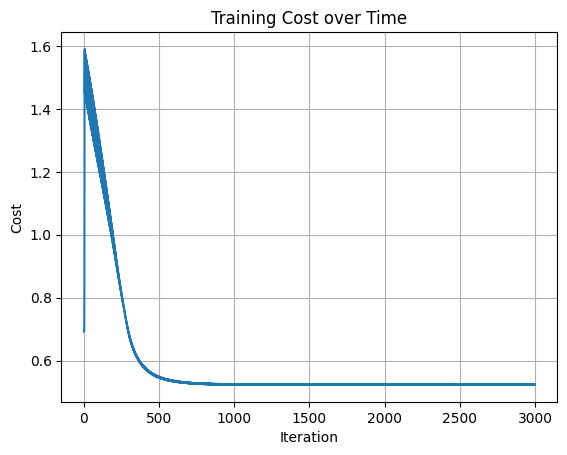

In [96]:
# Simple one-liner plot
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost over Time')
plt.grid(True)
plt.show()

## Part 5: Testing and Evaluation


### Milestone 5.1: Implement Prediction Function

**What to implement**: `predict_sentiment(review, freqs, theta)`

```python
def predict_sentiment(review, freqs, theta):
    """
    Predict sentiment for a single review

    Args:
        review: review text (string)
        freqs: frequency dictionary
        theta: trained parameters (3, 1)

    Returns:
        prediction: 1 (positive) or 0 (negative)
        probability: P(positive)
    """
    pass  # Your implementation here
```

Algorithm:

1. Extract features x
2. z = x · theta
3. h = sigmoid(z)
4. predict = 1 if h >= 0.5 else 0

In [97]:
def predict_sentiment(review, freqs, theta):
    """
    Predict sentiment for a single review

    Args:
        review: review text (string)
        freqs: frequency dictionary
        theta: trained parameters (3, 1)

    Returns:
        prediction: 1 (positive) or 0 (negative)
        probability: P(positive)
    """
    
    # extract the features of the review and store it into x
    x = extract_features(review, freqs)

     # Reshape x to (1, 3) for proper matrix multiplication
    x = x.reshape(1, -1) 

    # make prediction using the x and theta
    z = np.dot(x, theta)
    h = sigmoid(z)

    probability = float(h[0, 0])

    prediction = 1 if probability>=0.5 else 0

    return prediction, probability

In [98]:
# Test with a positive review
review = "This movie was absolutely fantastic!"
prediction, prob = predict_sentiment(review, freqs, theta)
print(f"Prediction: {prediction}, Probability: {prob:.3f}")

# Test with a negative review
review2 = "This movie was terrible and boring."
prediction2, prob2 = predict_sentiment(review2, freqs, theta)
print(f"Prediction: {prediction2}, Probability: {prob2:.3f}")

Prediction: 0, Probability: 0.396
Prediction: 0, Probability: 0.373


### Milestone 5.2: Evaluate on Test Set

**What to implement**: `test_model(X_test, y_test, theta)`

```python
def test_model(X_test, y_test, theta):
    """
    Evaluate model on test set

    Args:
        X_test: test feature matrix (m, 3)
        y_test: test labels (m, 1)
        theta: trained parameters (3, 1)

    Returns:
        accuracy: fraction of correct predictions
    """
    pass  # Your implementation here
```

Hints:

- Vectorize: `h = sigmoid(X_test @ theta)`
- Predictions: `(h >= 0.5).astype(int)`
- Accuracy: `np.mean(predictions == y_test)`
- Use same `freqs` and `theta` from training

In [99]:
# short form code -
# h = [0.8, 0.3, 0.6]
# h >= 0.5  →  [True, False, True]

h = np.array([0.8, 0.3, 0.6])
predictions = (h >= 0.5).astype(int)

print(predictions)

[1 0 1]


In [100]:
# or in simple terms
predictions = []
for prob in h:
    if prob >= 0.5:
        predictions.append(1)
    else:
        predictions.append(0)
predictions = np.array(predictions)
print(predictions)

[1 0 1]


In [101]:
import numpy as np

predictions = np.array([1, 0, 1, 0])
y_test = np.array([1, 1, 1, 0])

accuracy = np.mean(predictions == y_test)
print(accuracy)

0.75


In [102]:
def test_model(X_test, y_test, theta):
    """
    Evaluate model on test set

    Args:
        X_test: test feature matrix (m, 3)
        y_test: test labels (m, 1)
        theta: trained parameters (3, 1)

    Returns:
        accuracy: fraction of correct predictions
    """
    # compute predictions for all test example
    z = np.dot(X_test, theta)
    h = sigmoid(z)

    # predictions : 1 if h>=0.5 else 0
    predictions = (h>=0.5).astype(int)

    # compare with true  labels and calculate accuracy
    correct = (predictions == y_test)

    accuracy = np.mean(correct)

    return accuracy


In [103]:
X_test = X_test.flatten()
y_test = Y_test.flatten()

# Convert test labels to numeric
y_test_numeric = np.array([1 if label == 'positive' else 0 for label in y_test]).reshape(-1, 1)

# Build feature matrix for test set (use SAME freqs from training!)
test_features, _ = build_feature_matrix(X_test, y_test_numeric.flatten())

# Evaluate the model
print("Testing model on test reviews...")
accuracy = test_model(test_features, y_test_numeric, theta)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Test on training set to check for overfitting
print("\nTraining set accuracy:")
train_accuracy = test_model(features, Y_train_numeric, theta)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

Testing model on test reviews...
Accuracy: 0.8700 (87.00%)

Training set accuracy:
Training Accuracy: 0.7412 (74.12%)


## Part 6: Error Analysis


### Milestone 6.1: Find Misclassified Reviews

What to implement:

1. Loop through test set
2. Find reviews where prediction ≠ true label
3. Print review, true label, predicted label, and probability

Look for failure patterns:

- Sarcasm
- Negation
- Mixed sentiment
- Context-dependent words

Analyze at least 10-20 misclassified examples

In [104]:
def find_misclassified_reviews(test_reviews, y_test, freqs, theta, max_to_show=20):
    """
    Print misclassified reviews with details.
    
    Args:
        test_reviews: list of review texts
        y_test: true labels (list or numpy array)
        freqs: frequency dictionary
        theta: trained logistic regression parameters
        max_to_show: number of examples to print
    """
    misclassified = []

    for i, review in enumerate(test_reviews):
        prediction, prob = predict_sentiment(review, freqs, theta)
        true_label = y_test[i]

        if prediction != true_label:
            misclassified.append((review, true_label, prediction, prob))

    print(f"\nTotal misclassified: {len(misclassified)} / {len(test_reviews)}")

    for i, (review, true_label, prediction, prob) in enumerate(misclassified[:max_to_show]):
        print(f"Review: {review}")
        print(f"True label: {'positive' if true_label == 1 else 'negative'}")
        print(f"Predicted: {'positive' if prediction == 1 else 'negative'}")
        print(f"Probability (P(positive)): {prob:.3f}")


In [108]:
print("X_test shape ",X_test.shape)
print("y test numeric shape ",y_test_numeric.shape)
print("theta shape ",theta.shape)

X_test shape  (400,)
y test numeric shape  (400, 1)
theta shape  (3, 1)


In [107]:
find_misclassified_reviews(X_test, y_test_numeric.flatten(), freqs, theta)


Total misclassified: 123 / 400
Review: Today I found "They All Laughed" on VHS on sale in a rental. It was a really old and very used VHS, I had no information about this movie, but I liked the references listed on its cover: the names of Peter Bogdanovich, Audrey Hepburn, John Ritter and specially Dorothy Stratten attracted me, the price was very low and I decided to risk and buy it. I searched IMDb, and the User Rating of 6.0 was an excellent reference. I looked in "Mick Martin & Marsha Porter Video & DVD Guide 2003" and  wow  four stars! So, I decided that I could not waste more time and immediately see it. Indeed, I have just finished watching "They All Laughed" and I found it a very boring overrated movie. The characters are badly developed, and I spent lots of minutes to understand their roles in the story. The plot is supposed to be funny (private eyes who fall in love for the women they are chasing), but I have not laughed along the whole story. The coincidences, in a huge c

### Milestone 6.2: Test Your Own Reviews

Write 5-10 custom reviews and run `predict_sentiment` on them. Example:

```python
my_reviews = [
    "This film was a masterpiece of cinema!",
    "Boring and predictable, waste of time.",
    "Not the worst movie I've seen.",  # Tricky!
    "I loved hating every minute of it.",  # Super tricky!
]

for review in my_reviews:
    pred, prob = predict_sentiment(review, freqs, theta)
    print(f"Review: {review}")
    print(f"Prediction: {'Positive' if pred == 1 else 'Negative'} ({prob:.3f})\n")
```

In [110]:
# Create a list of custom reviews with varying sentiments
my_reviews = [
    # Clear positive reviews
    "This film was a masterpiece of cinema!",
    "Absolutely brilliant! Best movie I've seen this year.",
    "Amazing acting, wonderful story, highly recommend!",
    
    # Clear negative reviews
    "Boring and predictable, waste of time.",
    "Terrible movie, I couldn't even finish it.",
    "Awful acting and horrible plot. Don't watch this.",
    
    # Tricky/ambiguous reviews
    "Not the worst movie I've seen.",  # Tricky: uses negative words but implies it's okay
    "I loved hating every minute of it.",  # Super tricky: positive "loved" but negative context
    "This movie was something.",  # Neutral/vague
    "It had its moments but overall disappointing.",  # Mixed sentiment
]

print(f"\nTesting {len(my_reviews)} custom reviews:\n")

# Test each review and display results
for i, review in enumerate(my_reviews, 1):
    pred, prob = predict_sentiment(review, freqs, theta)
    
    # Determine sentiment label
    sentiment = 'Positive' if pred == 1 else 'Negative'
    
    # Determine confidence level
    confidence = max(prob, 1-prob)  # Distance from 0.5
    if confidence > 0.7:
        confidence_label = "(High confidence)"
    elif confidence > 0.6:
        confidence_label = "(Medium confidence)"
    else:
        confidence_label = "(Low confidence)"
    
    print(f"Review {i}: \"{review}\"")
    print(f"Prediction: {sentiment} | Probability: {prob:.3f} {confidence_label}")

print("ANALYSIS OF TRICKY REVIEWS")

# Analyze the tricky reviews specifically
tricky_reviews = [
    ("Not the worst movie I've seen.", 
     "Contains negation - model might struggle with double negatives"),
    ("I loved hating every minute of it.", 
     "Mixed sentiment - 'loved' is positive but 'hating' is negative"),
]

print("\nLet's see how the model handles these tricky cases:\n")

for review, explanation in tricky_reviews:
    pred, prob = predict_sentiment(review, freqs, theta)
    sentiment = 'Positive' if pred == 1 else 'Negative'
    
    print(f"Review: \"{review}\"")
    print(f"Why it's tricky: {explanation}")
    print(f"Model prediction: {sentiment} (probability: {prob:.3f})")
    print(f"Expected: This is ambiguous - could go either way!")


Testing 10 custom reviews:

Review 1: "This film was a masterpiece of cinema!"
Prediction: Positive | Probability: 0.585 (Low confidence)
Review 2: "Absolutely brilliant! Best movie I've seen this year."
Prediction: Negative | Probability: 0.464 (Low confidence)
Review 3: "Amazing acting, wonderful story, highly recommend!"
Prediction: Positive | Probability: 0.552 (Low confidence)
Review 4: "Boring and predictable, waste of time."
Prediction: Negative | Probability: 0.411 (Low confidence)
Review 5: "Terrible movie, I couldn't even finish it."
Prediction: Negative | Probability: 0.395 (Medium confidence)
Review 6: "Awful acting and horrible plot. Don't watch this."
Prediction: Negative | Probability: 0.420 (Low confidence)
Review 7: "Not the worst movie I've seen."
Prediction: Negative | Probability: 0.335 (Medium confidence)
Review 8: "I loved hating every minute of it."
Prediction: Positive | Probability: 0.576 (Low confidence)
Review 9: "This movie was something."
Prediction: Negat

## Submission Checklist

Before you finish, ensure all code and tests are implemented and pass. Key items:

- `process_review(review)`
- `build_freqs(reviews, labels)`
- `extract_features(review, freqs)`
- `build_feature_matrix(reviews, labels)`
- `sigmoid(z)`
- `gradient_descent(X, y, theta, alpha, num_iters)`
- `predict_sentiment(review, freqs, theta)`
- `test_model(X_test, y_test, theta)`

Make sure training cost decreases and test accuracy is reasonable (>75%).

## Reflection Questions

Answer these in comments or a separate document:

1. Preprocessing differences: How did preprocessing movie reviews differ from tweets?
2. Feature importance: Which feature (positive/negative freq) has more influence?
3. Learning rate: What happened with different rates?
4. Error patterns: Top 3 patterns in misclassified reviews?
5. Vocabulary size: How many unique words after preprocessing?
6. Improvements: Ideas to improve accuracy (no implementation required)
7. Naive Bayes preview: What will Naive Bayes do differently?

## Bonus Challenges (Optional)

Challenges:

- Multi-class classification (3 classes)
- Additional features: review length, punctuation counts, intensifiers
- Visualizations: cost vs iterations, ROC curve, feature distributions
- Hyperparameter tuning: different learning rates and iterations

## Hints for Common Struggles

- If cost increases: reduce learning rate, check gradient sign and shapes
- If accuracy stuck at 50%: verify theta updates and gradient calculation
- For numpy dimension errors: print shapes and use `.reshape(-1, 1)`
- For slow preprocessing: compile regex once, use list comprehensions
- For unknown words: use `freqs.get((word, label), 0)`

## Success Criteria

You have completed the assignment when:

- Model trains without errors
- Cost decreases during training
- Test accuracy between 75-90%
- You can explain your code and analyze misclassifications

## Key Takeaways

- Preprocessing is domain-specific
- Feature extraction connects text to math
- Gradient descent learns parameters from data
- Error analysis guides improvements

You're now ready for Week 2: Naive Bayes!

## Getting Help

If stuck:

1. Re-read Week 1 notes
2. Check unit tests
3. Print intermediate values
4. Start with a small subset of reviews
5. Compare with tweet-based implementations to spot differences

## Final Note

This assignment is intentionally challenging — movie reviews are more complex than tweets. Take your time and understand each step.

**Next Assignment**: Week 2 - Naive Bayes for Movie Genre Classification